## Análisis y Procesamiento de Señales, 2C 2026
### Escuela de Ciencia y Tecnología
#### Iara Alvarez Costa
# Tarea Semanal N°2

Para esta tarea, se busca simular el comportamiento del dispositivo al digitalizar una senoidal contaminada con un nivel predeterminado de ruido. Se pide utilizar una señal senoidal con de frecuencia $f_0$ arbitraria, (por ejemplo $f_0 = \frac{f_S}{N} = Δf$), y de energía normalizada, es decir energía (o varianza) unitaria.

Con respecto a los parámetros de la secuencia de ruido que usemos, se pide que sea de carácter aditivo, es decir la señal que entra al ADC será $s_R = s + n$, siendo $n$ la secuencia que simula la interferencia, y $s$ la senoidal descrita. La potencia del ruido será $P_n = k_n.P_q$ siendo el factor $k$ una escala para la potencia del ruido de cuantización $P_q = \frac{q^2}{12}$; y finalmente, $n$ deberá ser incorrelado y Gaussiano.
    
El ADC que deseamos simular trabajará a una frecuencia de muestreo $f_S=1000 Hz$ y tendrá un rango analógico de $±V_f = 2 Volts$.

Se pide:

   $a)$ Generar el resultado de la experimentación con un ADC de $B = 4$ bits, $k_n=1$. Graficar amplitud de señal, densidad de potencia en dB, y ruido  de cuantización en forma de un histograma.
   
   $b)$ Analizar para una de las siguientes configuraciones B =  ̣{4, 8, 16} bits, $k_n = $ {1/10 , 1 , 10}. Discutir los resultados respecto a lo obtenido en a)da de Fourier.

# Introducción


### Señal

Para generar la señal senoidal que me piden antes de empezar, voy a hacer uso del código que ya escribí para la tarea anterior. Definiré la frecuencia de la señal como $f_0 = \frac{f_S}{N}$ como sugiere el enunciado; y, si decido definir la señal para que tenga media 0, entonces... $Var(x) = \frac{A^2}{2}$ y $A=√2$ para una varianza unitaria.


### Ruido analógico

Se pide que la secuencia aleatoria $n$ con la que voy a simular la contaminación de la senoide de forma aditiva sea gaussiana e incorrelada. Esto significa que me conviene generar el ruido con la función $np.random.normal(µ , σ , N)$. Como ya sé, definiendo una media $µ=0$, el desvía estándar de la secuencia se puede relacionar directamente con la potencia del ruido, de forma que $P_n=σ^2$.

Ahora, en este caso, la secuencia va a estar definida en base a la potencia del ruido de cuantización $(P_q)$ que, a su vez, depende del paso de cuantización $q$. Este último valor ($q$) define el tamaño del intervalo entre dos niveles consecutivos en el rango de valores discretos en los que se categorizarán las muestras durante el proceso de digitalización de la señal analógica. Vamos a definir este paso de cuantización en base al rango analógico $V_f$, y la cant. de bits $(B)$ que define la resolución del ADC:
<div align="center"> $q = \frac{2.V_f}{2^B} = \frac{4}{2^B}$ </div>
Una vez definido $q$, la potencia del ruido de cuantización quedará $P_q = \frac{q^2}{12}$, y la potencia del ruido analógico quedará definida como $P_n = k_n.P_q=σ^2$, y por lo tanto, el desvío estándar del ruido analógico:

<div align="center"> $σ=√(k_n.P_q)$ </div>

In [5]:
import numpy as np
import matplotlib.pyplot as plt

"___________________________________ Definicion de constantes _____________________________________"

"Parámetros de senoidal"
fs = 1000 #Frecuencia muestreo [Hz] 
N = 1000 #Cant. muestras
vmax = np.sqrt(2) #Amp max senoidal
dc = 0 #Offset senoidal
ff = fs/N #Frecuencia sinusoidal [Hz]
ph = 0 #Fase sinusoidal [rad]

"Parámetros secuencia de ruido"
ur = 0 #Media del ruido 

"Parámetros ADC"
Vf = 2 #Rango análógico del ADC


In [6]:
"____________________________________________ Funciones ___________________________________________"

# Generador de señal senoidal
def gen_sin (vmax = 1, dc = 0, ff = 1, ph=0, nn = N, fs = fs):

    #genero un vector de valores de 0 a N/fs segundos a intervalos de 1/fs
    tt = np.arange(0, stop=nn/fs, step=1/fs)
    #genero un vector con los valores de 'dc + vmax.Sen(2pi.ff.tt + ph)' para cada valor de tt
    xx = dc + vmax * np.sin (2 * np.pi * ff * tt + ph)
    
    return tt, xx 


# Generador de ruido analógico
def gen_noise (q, k = k, ur = ur, nn = N):

    #Defino la potencia del ruido de cuantización en funcion a q
    Pq = q**2/12
    #Defino la potencia del ruido en función de Pq y k   
    Pr = Pq * k
    #calculo la desviación estandar del ruido en base a Pr (Pr = σr^2)
    desv_est_r = np.sqrt(Pr)
    
    #genero un vector de nros aleatorios de distribucion normal
    ruido = np.random.normal(ur, desv_est_r, nn)
    
    return ruido


# Funcion de cuantización de señales
def cuantizador (x, B = 4, Vf = 2):
    
    #defino el paso de cuantización
    q = 2*Vf/(2**B)
    #Restrinjo los valores de la señal contaminada entre +/- Vf
    x_sat = np.clip(x, -Vf, Vf)
    
    x_quant = np.round(x_sat/q)*q

    #calculo ruido de cuantización
    nq = x_quant - x
    
    return x_quant, nq, q


# Funcion transformadora de las señales
def transformer_fft (x, n_analog, n_quant, N = N):
    
    #Calculo FFT normalizada
    X_fft = 1/N * np.fft.fft(x)
    n_fft = 1/N * np.fft.fft(n_analog)
    nq_fft = 1/N * np.fft.fft(n_quant)
    #Selecciono las frecuencias positivas
    X_fft = X_fft[:N//2]
    n_fft = n_fft[:N//2]
    nq_fft = nq_fft[:N//2]
    #magnitud en dB
    X_dB = 20 * np.log10(np.abs(X_fft))
    n_dB = 20 * np.log10(np.abs(n_fft))
    nq_dB = 20 * np.log10(np.abs(nq_fft))
    
    return X_dB, n_dB, nq_dB

    

Antes de empezar a resolver los incisos del enunciado, necesito comprobar la correlación de la secuencia aleatoria normal para verificar que el ruido analógico que generé sea incorrelado, como se pide. 

Si bautizo a la secuencia aleatoria generada como $r[n]$, puedo definir:

<div align="center"> $R_r(h)=$ Valor esperado$(r[n].r[n-h]) = E$ {$r[n].r[n-h]$}, con $h =$ {$0,1,2,...$}</div>
|

Para hacer esto con el programa, usaré la función $np.correlate()$ de la librería $numpy$


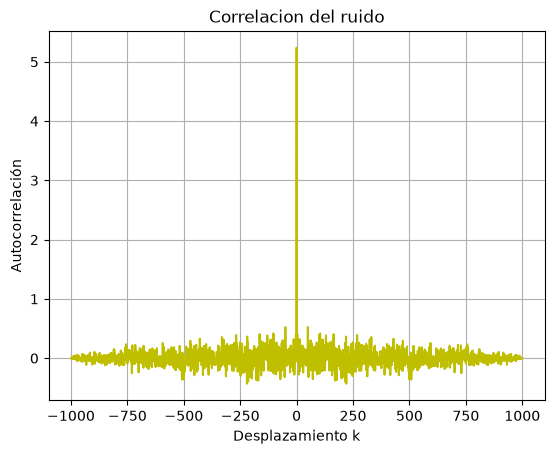

In [28]:
"____________________________________________ Main Script ___________________________________________"

"Genero ruido analógico"
ruido_analog_1 = gen_noise(q1, 1, ur, N)

"Genero señal"
tt, xsen = gen_sin (vmax, dc, ff, ph, N, fs)

"Contamino la señal"
noisy_xsen_1 = xsen + ruido_analog_1

"Cuantizacion de señal"
B1 = 4
xsen_quant_1, n_quant_1, q1 = cuantizador (noisy_xsen_1, B1, Vf)

#Compruebo que el ruido de cuantizacion sea incorrelado
Rn = np.correlate (n_quant_1, n_quant_1, mode='full')
vector_desplazamientos = np.arange(-N+1, N)

plt.plot(vector_desplazamientos, Rn, 'y')
plt.title('Correlacion del ruido')
plt.xlabel("Desplazamiento k")
plt.ylabel("Autocorrelación")
plt.grid()
plt.show()

Para una secuencia incorrelada, se cumpliría $R_r(h)≈0$, para todo $h≠0$, ya que $R_r(0)=E$ {${r[n]}^2$} $≈P_n$, lo cual se observa claramente en el gráfico.

### Inciso $a)$:

Se me pide graficar la amplitud de señal, densidad de potencia, y ruido de cuantización en forma de un histograma, para $B=4$ bits, y $k_n=1$

C:\Users\Iarulis\AppData\Local\Temp\ipykernel_13140\2930068155.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


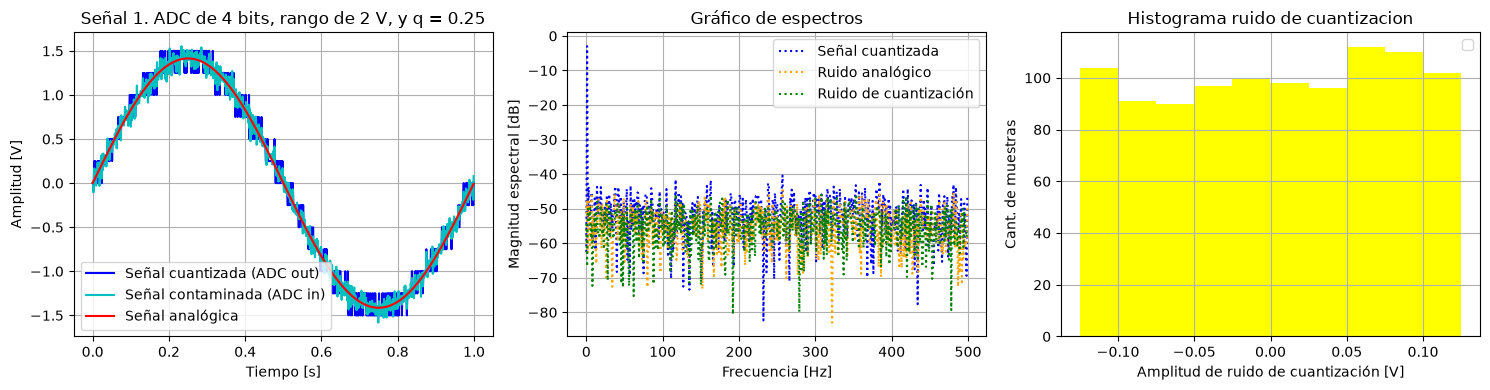

In [30]:
"____________________________________________ Inciso a) ___________________________________________"

#(Ya armé las señales y secuencias de ruido que necesito para comprobar la incorrelación del nq)

"Transformo todo lo que me interesa ver en el espectro"
fft_quant, fft_nq, fft_analog = transformer_fft (xsen_quant_1, ruido_analog_1, n_quant_1, N)

#Armo vector de frecuencias
frec = np.arange(N//2) * fs/N

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

"Gráfico de señales"
axs[0].plot(tt, xsen_quant_1, color='b', label="Señal cuantizada (ADC out)")
axs[0].plot(tt, noisy_xsen_1, color='c', label="Señal contaminada (ADC in)")
axs[0].plot(tt, xsen, color='r', label="Señal analógica")
axs[0].set_title(f"Señal 1. ADC de {B1} bits, rango de {Vf} V, y q = {q1}")
axs[0].set_xlabel('Tiempo [s]')
axs[0].set_ylabel ('Amplitud [V]')

"Gráfico de espectros"
axs[1].plot(frec, fft_quant, color='blue', linestyle=':', label="Señal cuantizada")
axs[1].plot(frec, fft_analog, 'orange', linestyle=':', label="Ruido analógico")
axs[1].plot(frec, fft_nq, 'green', linestyle=':', label="Ruido de cuantización")
axs[1].set_title('Gráfico de espectros')
axs[1].set_xlabel('Frecuencia [Hz]')
axs[1].set_ylabel ('Magnitud espectral [dB]')

"Histograma"
axs[2].hist(n_quant_1, color='yellow')
axs[2].set_title('Histograma ruido de cuantizacion')
axs[2].set_xlabel('Amplitud de ruido de cuantización [V]')
axs[2].set_ylabel ('Cant. de muestras')

for ax in axs.flat:
    ax.grid()
    ax.legend()

plt.tight_layout()
plt.show()


#### Análisis

Para un ADC de 4 bits y rango de 2 Volts, la resolución es bastante baja. El paso de cuantización para ese caso es $q=\frac{2.2}{2^4}=0,25 V$, y el efecto de la cuantización de la señal analógica es muy visiblemente evidente en el primer gráfico.

Se puede ver un pico de magnitud en el espectro de la señal cuantizada, lo cual es coherente con la senoidal conservando su componente fundamental en 1 Hz. 
Como $k_n=1$, las potencias del ruido analógico y de cuantización $P_n=k_n.P_q=P_q$ son iguales, lo cual se evidencia en los similares pisos de ruido superpuestos en el gráfico de espectros.

Como el ADC funciona con una frecuencia de muestreo $f_s=1000Hz$ y $N=1000$, la separación entre bins de fft es $Δf=1Hz$

En el histograma, podemos observar que la distribución estadpistica del ruido de cuantización se limita a un cierto rango de amplitudes. Esto es coherente con la predicción del modelo ideal de cuantización, segun la cual el ruido de cuantización $n_q[n]=X_{ADC in}[n]−X_{ADC out}[n]$, está contenido entre $-\frac{q}{2} ≤ n_q[n] ≤ \frac{q}{2}$, en este caso:
$-0.125 ≤ n_q[n] ≤ 0.125$, lo cual se evidencia en el histograma.

### Inciso $b)$:

Se me pide repetir lo realizado en a) para las configuraciones: B =  ̣{4, 8, 16} bits, $k_n = $ {1/10 , 1 , 10}.

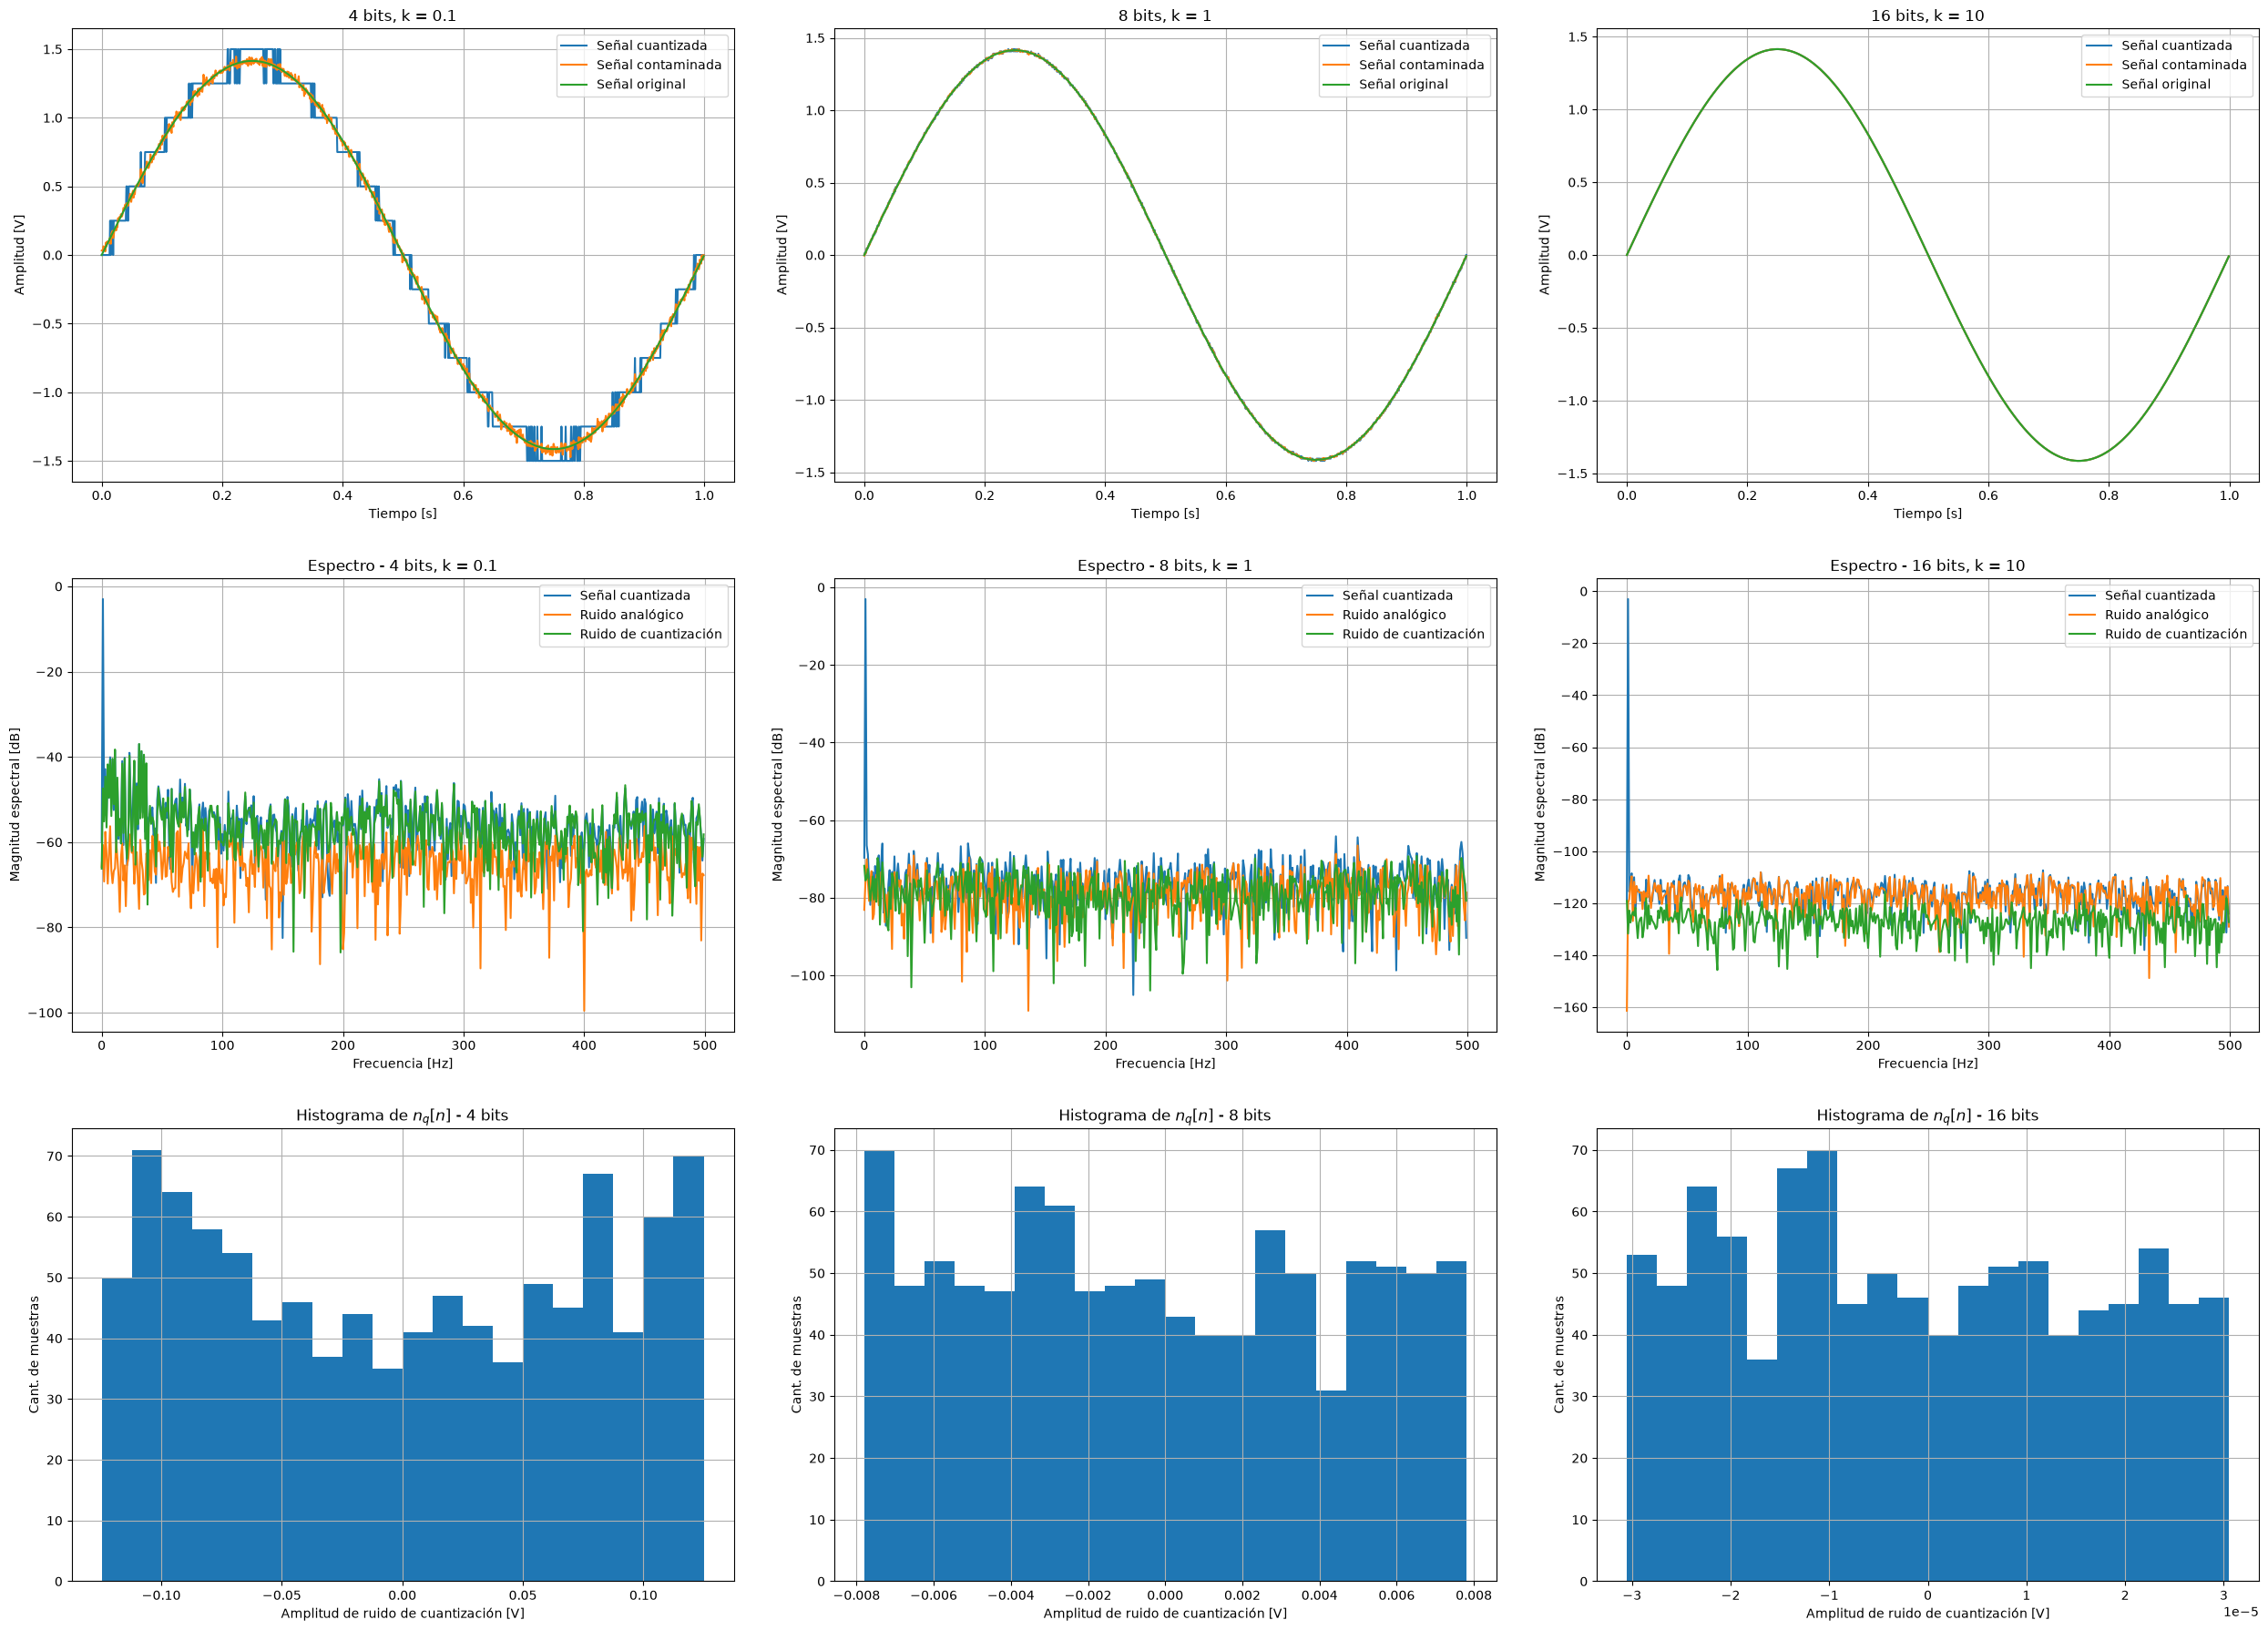

In [31]:
"____________________________________________ Inciso b) ___________________________________________"

"Parámetros ADC para cada caso"
casos = [{"B": 4, "k": 0.1} , {"B": 8, "k": 1} , {"B": 16, "k": 10}]

resultados = []

for caso in casos:

    B = caso["B"]
    k = caso["k"]
    # Paso de cuantización
    q = 2*Vf/(2**B)
    # Genero ruido analógico
    ruido = gen_noise(q, k, ur, N)
    # Contamino la señal
    noisy = xsen + ruido
    # Cuantizo la señal contaminada
    x_quant, nq, q = cuantizador(noisy, B, Vf)
    # Transformo mediante FFT
    X_dB, ruido_dB, nq_dB = transformer_fft(x_quant, ruido, nq, N)

    # Guardo todos los resultados
    resultados.append({
        "B": B,
        "k": k,
        "q": q,
        "ruido": ruido,
        "noisy": noisy,
        "quant": x_quant,
        "nq": nq,
        "X_dB": X_dB,
        "ruido_dB": ruido_dB,
        "nq_dB": nq_dB
    })

fig, axs = plt.subplots(3, 3, figsize=(25, 18))

"Grafico señales"
for i, resultado in enumerate(resultados):

    axs[0,i].plot(tt, resultado["quant"], label="Señal cuantizada")
    axs[0,i].plot(tt, resultado["noisy"], label="Señal contaminada")
    axs[0,i].plot(tt, xsen, label="Señal original")
    
    axs[0,i].set_title(f'{resultado["B"]} bits, k = {resultado["k"]}')
    axs[0,i].set_xlabel("Tiempo [s]")
    axs[0,i].set_ylabel("Amplitud [V]")
    axs[0,i].grid()
    axs[0,i].legend()


"Grafico espectros"
for i, resultado in enumerate(resultados):

    axs[1,i].plot(frec, resultado["X_dB"], label="Señal cuantizada")
    axs[1,i].plot(frec, resultado["ruido_dB"], label="Ruido analógico")
    axs[1,i].plot(frec, resultado["nq_dB"], label="Ruido de cuantización")
    axs[1,i].set_title(f'Espectro - {resultado["B"]} bits, k = {resultado["k"]}')

    axs[1,i].set_xlabel("Frecuencia [Hz]")
    axs[1,i].set_ylabel("Magnitud espectral [dB]")
    axs[1,i].grid()
    axs[1,i].legend()


"Histogramas"
for i, resultado in enumerate(resultados):

    axs[2,i].hist(resultado["nq"], bins=20)
    axs[2,i].set_title(f'Histograma de $n_q[n]$ - {resultado["B"]} bits')

    axs[2,i].set_xlabel("Amplitud de ruido de cuantización [V]")
    axs[2,i].set_ylabel("Cant. de muestras")
    axs[2,i].grid()


plt.tight_layout(w_pad=3, h_pad=3)
plt.show()


#### Análisis

